In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sklearn
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
import os

ticker = "AAPL"

if not os.path.exists('aapl_data.csv'):
    data = yf.download(ticker, start="2021-01-01", end="2026-01-24")
    data.to_csv('aapl_data.csv')
data = pd.read_csv('aapl_data.csv', skiprows=[1, 2], index_col=0, parse_dates=True).rename_axis('Date')
print(data.head())
print(data.dtypes)

                 Close        High         Low        Open     Volume
Date                                                                 
2021-01-04  125.974464  130.062961  123.394814  129.975354  143301900
2021-01-05  127.532005  128.242636  125.020496  125.468291   97664900
2021-01-06  123.239059  127.570927  123.024899  124.329329  155088000
2021-01-07  127.444359  128.135516  124.465598  124.952324  109578200
2021-01-08  128.544373  129.108977  126.772682  128.914274  105158200
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object


though examples, gave prediction based on only closing price, but I thought that tking both the price and volume will give better result

In [3]:
df = data[['Close', 'Volume']].copy()
df.rename(columns={'Close': 'price'}, inplace=True)
df.dropna(inplace=True)

df=df.asfreq('B')      # business days, as arima expects regular frequency
df.ffill(inplace=True)          


df['log_volume'] = np.log(df['Volume'])
df['log_vol_lag1'] = df['log_volume'].shift(1)
df.dropna(inplace=True)
print(df.head())

                 price       Volume  log_volume  log_vol_lag1
Date                                                         
2021-01-05  127.532005   97664900.0   18.397053     18.780464
2021-01-06  123.239059  155088000.0   18.859503     18.397053
2021-01-07  127.444359  109578200.0   18.512149     18.859503
2021-01-08  128.544373  105158200.0   18.470976     18.512149
2021-01-11  125.555870  100384500.0   18.424518     18.470976


In [4]:
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test  = df.iloc[train_size:]

y_train = train['price']
y_test  = test['price']

X_train = train[['log_vol_lag1']]
X_test  = test[['log_vol_lag1']]

In [5]:
model = ARIMA(
    y_train,
    exog=X_train,
    order=(5,1,0) #here 5 means, that prediction is based on last 5 days
)
fit = model.fit()

I have to assume the future volume as roughly equal to present volume, as arimax expected that.

also i will now test the accuracy, and for that i could use a rolling prediction, but then my cpu was taking too much time, so, forecasting over the test period only

In [6]:
pred = fit.forecast(
    steps=len(y_test),
    exog=X_test
)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("MAE:", mae)
print("RMSE:", rmse)


MAE: 23.56729459135149
RMSE: 27.550242783181126


the logic to fit each time is because as market evolves with time, our model accuracy has to be based on prev 5 days always

In [7]:
final_model = ARIMA(
    df['price'],
    exog=df[['log_vol_lag1']],
    order=(5,1,0)
)
final_fit = final_model.fit()

last_log_vol = df['log_vol_lag1'].iloc[-1]
future_exog = np.full((7, 1), last_log_vol)

forecast = final_fit.get_forecast(
    steps=7,
    exog=future_exog
)

mean_forecast = forecast.predicted_mean
conf_int = forecast.conf_int()

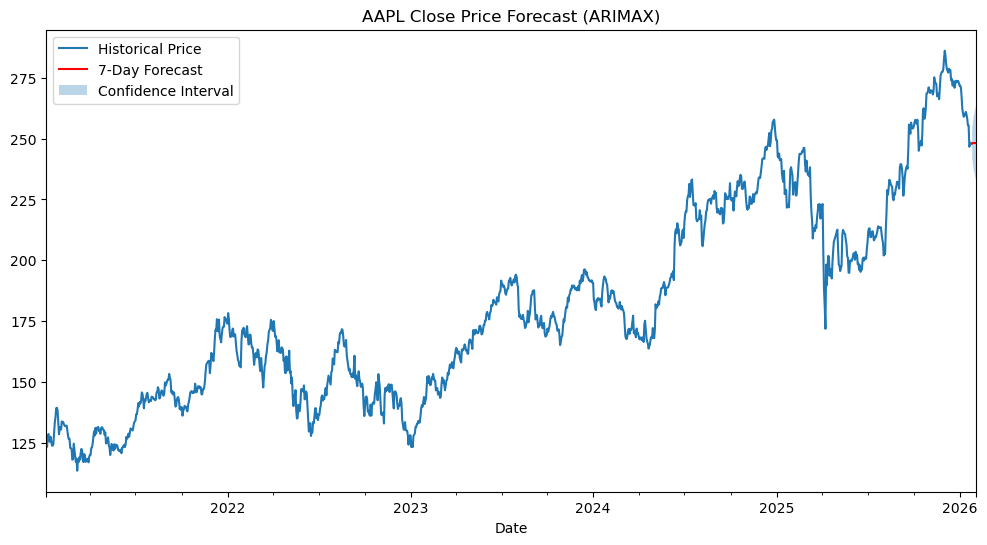

In [ ]:
plt.figure(figsize=(12,6))

df['price'].plot(label='Historical Price')
mean_forecast.plot(color='red', label='7-Day Forecast')

plt.fill_between(
    conf_int.index,
    conf_int.iloc[:,0],
    conf_int.iloc[:,1],
    alpha=0.3,
    label='Confidence Interval'
)

plt.title(f"{ticker} Close Price Forecast (All historical)")
plt.legend()
plt.show()

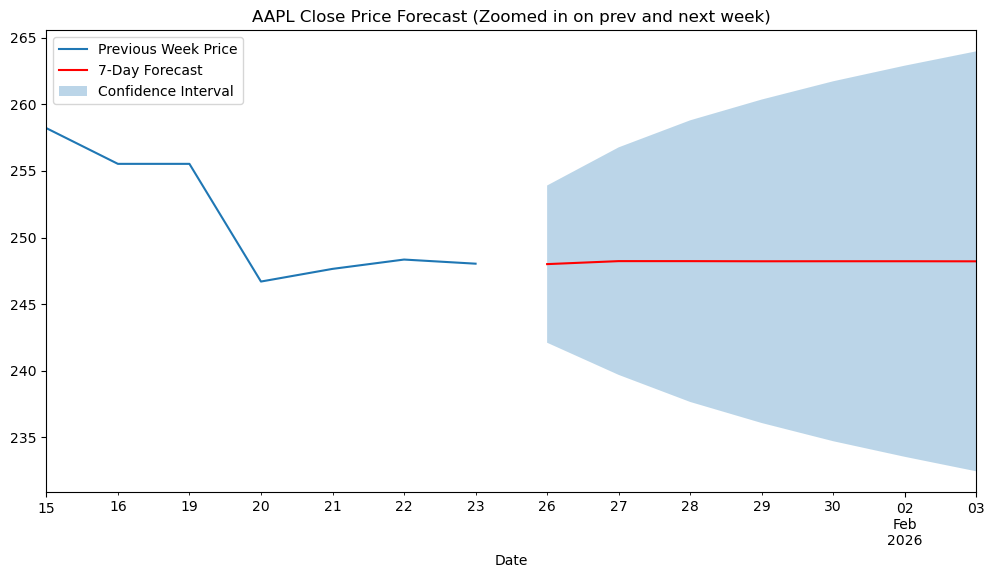

In [13]:
prev_week = df['price'].iloc[-7:]
plt.figure(figsize=(12,6))

df['price'].iloc[-7:].plot(label='Previous Week Price')
mean_forecast.plot(color='red', label='7-Day Forecast')

plt.fill_between(
    conf_int.index,
    conf_int.iloc[:,0],
    conf_int.iloc[:,1],
    alpha=0.3,
    label='Confidence Interval'
)
plt.title(f"{ticker} Close Price Forecast (Zoomed in on prev and next week)")
plt.legend()
plt.show()